In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import torch
import importlib_resources
from dtuimldmtools import rlr_validate, draw_neural_net, train_neural_net
from sklearn import model_selection, linear_model as lm
from scipy.linalg import svd
from scipy.io import loadmat
from scipy import stats

save_dir = 'plots'
os.makedirs(save_dir, exist_ok=True)  # Create the directory if it doesn't exist

# Open and filter data

In [11]:
# Read the data
df = pd.read_csv(
    '../dataset/auto-mpg.data',
    sep=r'\s+',
    names=[
        "mpg", "cylinders", "displacement", "horsepower",
        "weight", "acceleration", "model_year", "origin", "car_name"
    ],
    na_values=['?']  # Converts only '?' to NaN
).dropna()

# from https://github.com/Munees11/Auto-MPG-prediction/blob/master/Scripts/Auto%20MPG%20Predictions.ipynb
# df['brand'] = df["car_name"].str.extract('(^.*?)\s')
# df["origin"] = df["origin"].apply(lambda x: "USA" if x == 1 else ("Europe" if x == 2 else "Japan"))

# Drop the non-continuous columns
continous_columns = [col for col in df.columns if col not in ['model_year', 'origin', 'car_name']]
df_continous = df[continous_columns].copy()

# Drop the non-numerical columns
numerical_columns = [col for col in df.columns if col not in ['car_name']]
df_numerical = df[numerical_columns].copy()

# Make the cylinders attribute as continuous
df_continous['cylinders'] = (df_continous['cylinders'] - df_continous['cylinders'].min()) / (df_continous['cylinders'].max() - df_continous['cylinders'].min())
df_numerical['cylinders'] = (df_numerical['cylinders'] - df_numerical['cylinders'].min()) / (df_numerical['cylinders'].max() - df_numerical['cylinders'].min())

df

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,car_name
0,18.0,8,307.0,130.0,3504.0,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693.0,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150.0,3436.0,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150.0,3433.0,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140.0,3449.0,10.5,70,1,ford torino
...,...,...,...,...,...,...,...,...,...
393,27.0,4,140.0,86.0,2790.0,15.6,82,1,ford mustang gl
394,44.0,4,97.0,52.0,2130.0,24.6,82,2,vw pickup
395,32.0,4,135.0,84.0,2295.0,11.6,82,1,dodge rampage
396,28.0,4,120.0,79.0,2625.0,18.6,82,1,ford ranger


# Regression part A

Introduce a regularization parameter λ as discussed in chapter 14 of the lecture notes, and
estimate the generalization error for different values of λ. Specifically, choose a reasonable
range of values of λ (ideally one where the generalization error first drop and then in-
creases), and for each value use K = 10 fold cross-validation (algorithm 5) to estimate the
generalization error. Include a figure of the estimated generalization error as a function of
λ in the report and briefly discuss the result

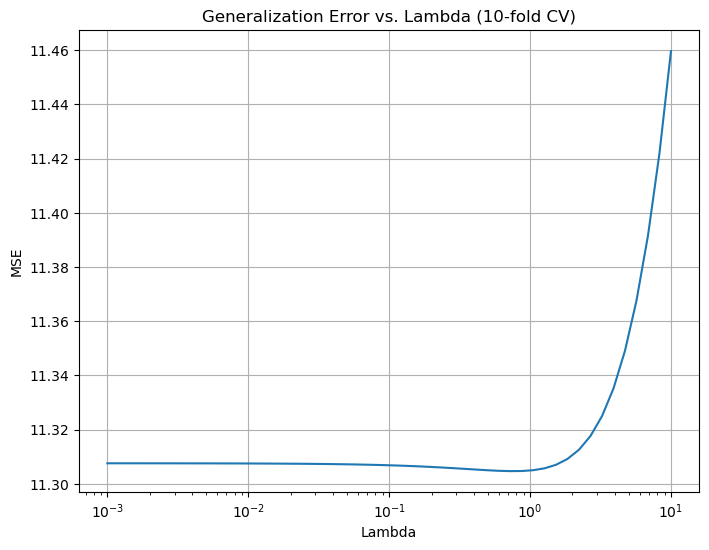

MPG regression function for optimal lambda (0.720): y =
        23.45 +       (bias)
     -0.80 x1 +       (cylinders)
      1.90 x2 +       (displacement)
     -0.67 x3 +       (horsepower)
     -5.35 x4 +       (weight)
      0.19 x5 +       (acceleration)
      2.75 x6 +       (model_year)
      1.14 x7 +       (origin)


In [12]:
# Convert DataFrame to a NumPy array
data_matrix = df_numerical.to_numpy()
attributeNames = df_numerical.columns

X = data_matrix[:, 1:]
y = data_matrix[:, 0]

# Add offset
X = np.concatenate((np.ones((X.shape[0], 1)), X), 1)
attributeNames = ["bias"] + list(attributeNames[1:])

lambdas = np.logspace(-3, 1, 50)

# Set up 10-fold cross-validation
K = 10
CV = model_selection.KFold(K, shuffle=True)

# Initialize arrays to store parameters
test_errors = np.zeros((K, len(lambdas)))
w_matrix = np.zeros((K, X.shape[1], len(lambdas)))

# Outer loop for K-fold cross-validation
k = 0
for train_index, test_index in CV.split(X, y):
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

    # Standardize data based on training set
    mu = np.mean(X_train[:, 1:], 0)
    sigma = np.std(X_train[:, 1:], 0)
    X_train[:, 1:] = (X_train[:, 1:] - mu) / sigma
    X_test[:, 1:] = (X_test[:, 1:] - mu) / sigma

    # Inner loop to evaluate different lambda values
    for i, lambda_val in enumerate(lambdas):
        # Calculate weights using linear algebra
        N, M = X_train.shape
        Xty = X_train.T @ y_train
        XtX = X_train.T @ X_train
        lambdaI = lambda_val * np.eye(M)
        lambdaI[0, 0] = 0  # Do not regularize the bias term
        w = np.linalg.solve(XtX + lambdaI, Xty)
        w_matrix[k, :, i] = w

        # Predict on the test set and calculate error
        y_pred = X_test @ w
        test_errors[k, i] = np.mean((y_test - y_pred)**2)
    k += 1

# Calculate the average test error for each lambda value across all folds
mean_test_errors = np.mean(test_errors, axis=0)

# Find the optimal lambda value (minimum generalization error)
optimal_lambda_idx = np.argmin(mean_test_errors)

# Find the corresponding weights to the optimal lambda
weights_per_optimal_lambda = w_matrix[:, :, optimal_lambda_idx]
mean_weights = np.mean(weights_per_optimal_lambda, axis=0)

# Plot the generalization error (average test error) against lambda values
plt.figure(figsize=(8, 6))
plt.plot(lambdas, mean_test_errors)
plt.xscale('log')
plt.xlabel('Lambda')
plt.ylabel('MSE')
plt.title('Generalization Error vs. Lambda (10-fold CV)')
plt.grid(True)
plt.show()

print(f"MPG regression function for optimal lambda ({lambdas[optimal_lambda_idx]:.3f}): y =")
for i, weight in enumerate(mean_weights):
  if i == 0:
    print(f"{weight:>13.2f} + {'':>5} ({attributeNames[i]})")
  else:
    print(f"{weight:>10.2f} x{i} + {'':>5} ({attributeNames[i]})")


# Regression part B

Implement two-level cross-validation (see algorithm 6 of the lecture notes). We will use 2-level cross-validation to compare the models with K1 = K2 = 10 folds2. As a baseline model, we will apply a linear regression model with no features, i.e. it computes the mean of y on the training data, and use this value to predict y on the test data. Make sure you can fit an ANN model to the data. As complexity-controlling parameter for the ANN, we will use the number of hidden units3 h. Based on a few test-runs, select a reasonable range of values for h (which should include h = 1), and describe the range of values you will use for h and λ.

In [13]:
# input must be ndarrays!
def ann_validate(X, y, hidden_units, internal_K, max_iter=10000, n_replicates=1):
    CV_internal = model_selection.KFold(internal_K, shuffle=True)
    loss_fn = torch.nn.MSELoss()
    
    best_h = None
    best_mse = float("inf")
    
    for h in hidden_units:
        se = []
        for k, (train_index, test_index) in enumerate(CV_internal.split(X, y)):
            X_train, y_train = torch.Tensor(X[train_index]), torch.Tensor(y[train_index])
            X_test, y_test = torch.Tensor(X[test_index]), torch.Tensor(y[test_index])

            model = lambda: torch.nn.Sequential(
                torch.nn.Linear(X_train.shape[1], h),
                torch.nn.Tanh(),
                torch.nn.Linear(h, 1)
            )
            
            net, _, _ = train_neural_net(
                model, 
                loss_fn, 
                X=X_train, 
                y=y_train, 
                n_replicates=n_replicates, 
                max_iter=max_iter
            )
            
            y_test_est = net(X_test).detach()
            se.append((y_test_est.float() - y_test.float()) ** 2)  # squared error
        
        mse = np.mean(np.concatenate(se))
        print(f"\n\nMSE error for ANN with h = {h} units after cv ==> {mse}")
        if mse < best_mse:
            best_mse = mse
            best_h = h
            
    return best_h, best_mse


	Replicate: 1/1
		Iter	Loss			Rel. loss
		1000	452.11835	0.0002370681
		2000	366.8841	0.00019618415
		3000	302.0749	0.00019453924
		4000	248.09169	0.00019972716
		5000	202.48306	0.00020651457
		6000	164.23451	0.00021178661
		7000	132.38608	0.00021687185
		8000	106.299484	0.00022273265
		Final loss:
		8000	106.299484	0.00022273265

	Replicate: 1/1
		Iter	Loss			Rel. loss
		1000	496.07492	0.00018138392
		2000	415.00854	0.00017718751
		3000	347.0906	0.00018100264
		4000	288.66888	0.00018803746
		5000	238.26515	0.0001958637
		6000	195.16425	0.00020339429
		7000	158.6369	0.00021031647
		8000	128.03488	0.00021733127
		Final loss:
		8000	128.03488	0.00021733127

	Replicate: 1/1
		Iter	Loss			Rel. loss
		1000	532.0337	0.00020461944
		2000	407.78305	0.00020344253
		3000	335.2592	0.00019312161
		4000	276.00168	0.0001969974
		5000	225.80437	0.00020457603
		6000	183.29372	0.0002122367
		7000	147.7869	0.0002181167
		8000	118.269325	0.00022643858
		Final loss:
		8000	118.269325	0.00022643858


MSE 

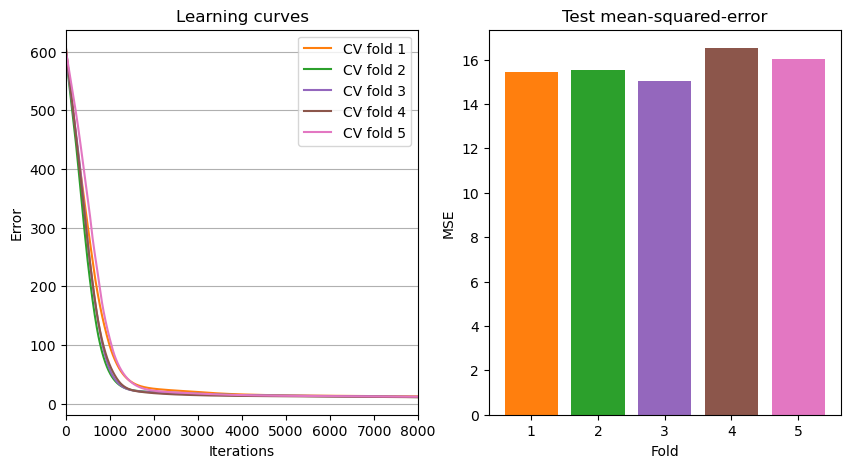

Baseline (no features):
- Training error: 60.7307283320064
- Test error: 60.25366594062446

Linear regression without feature selection (regularization):
- Training error: 103.78302247788841
- Test error: 104.08122812507463

Regularized linear regression:
- Training error: 102.9374064005962
- Test error: 103.22475391261227

Artificial Neural Network:
- Training error: 11.407601356506348
- Test error: 15.70272274017334

Diagram of best neural net from the last fold:


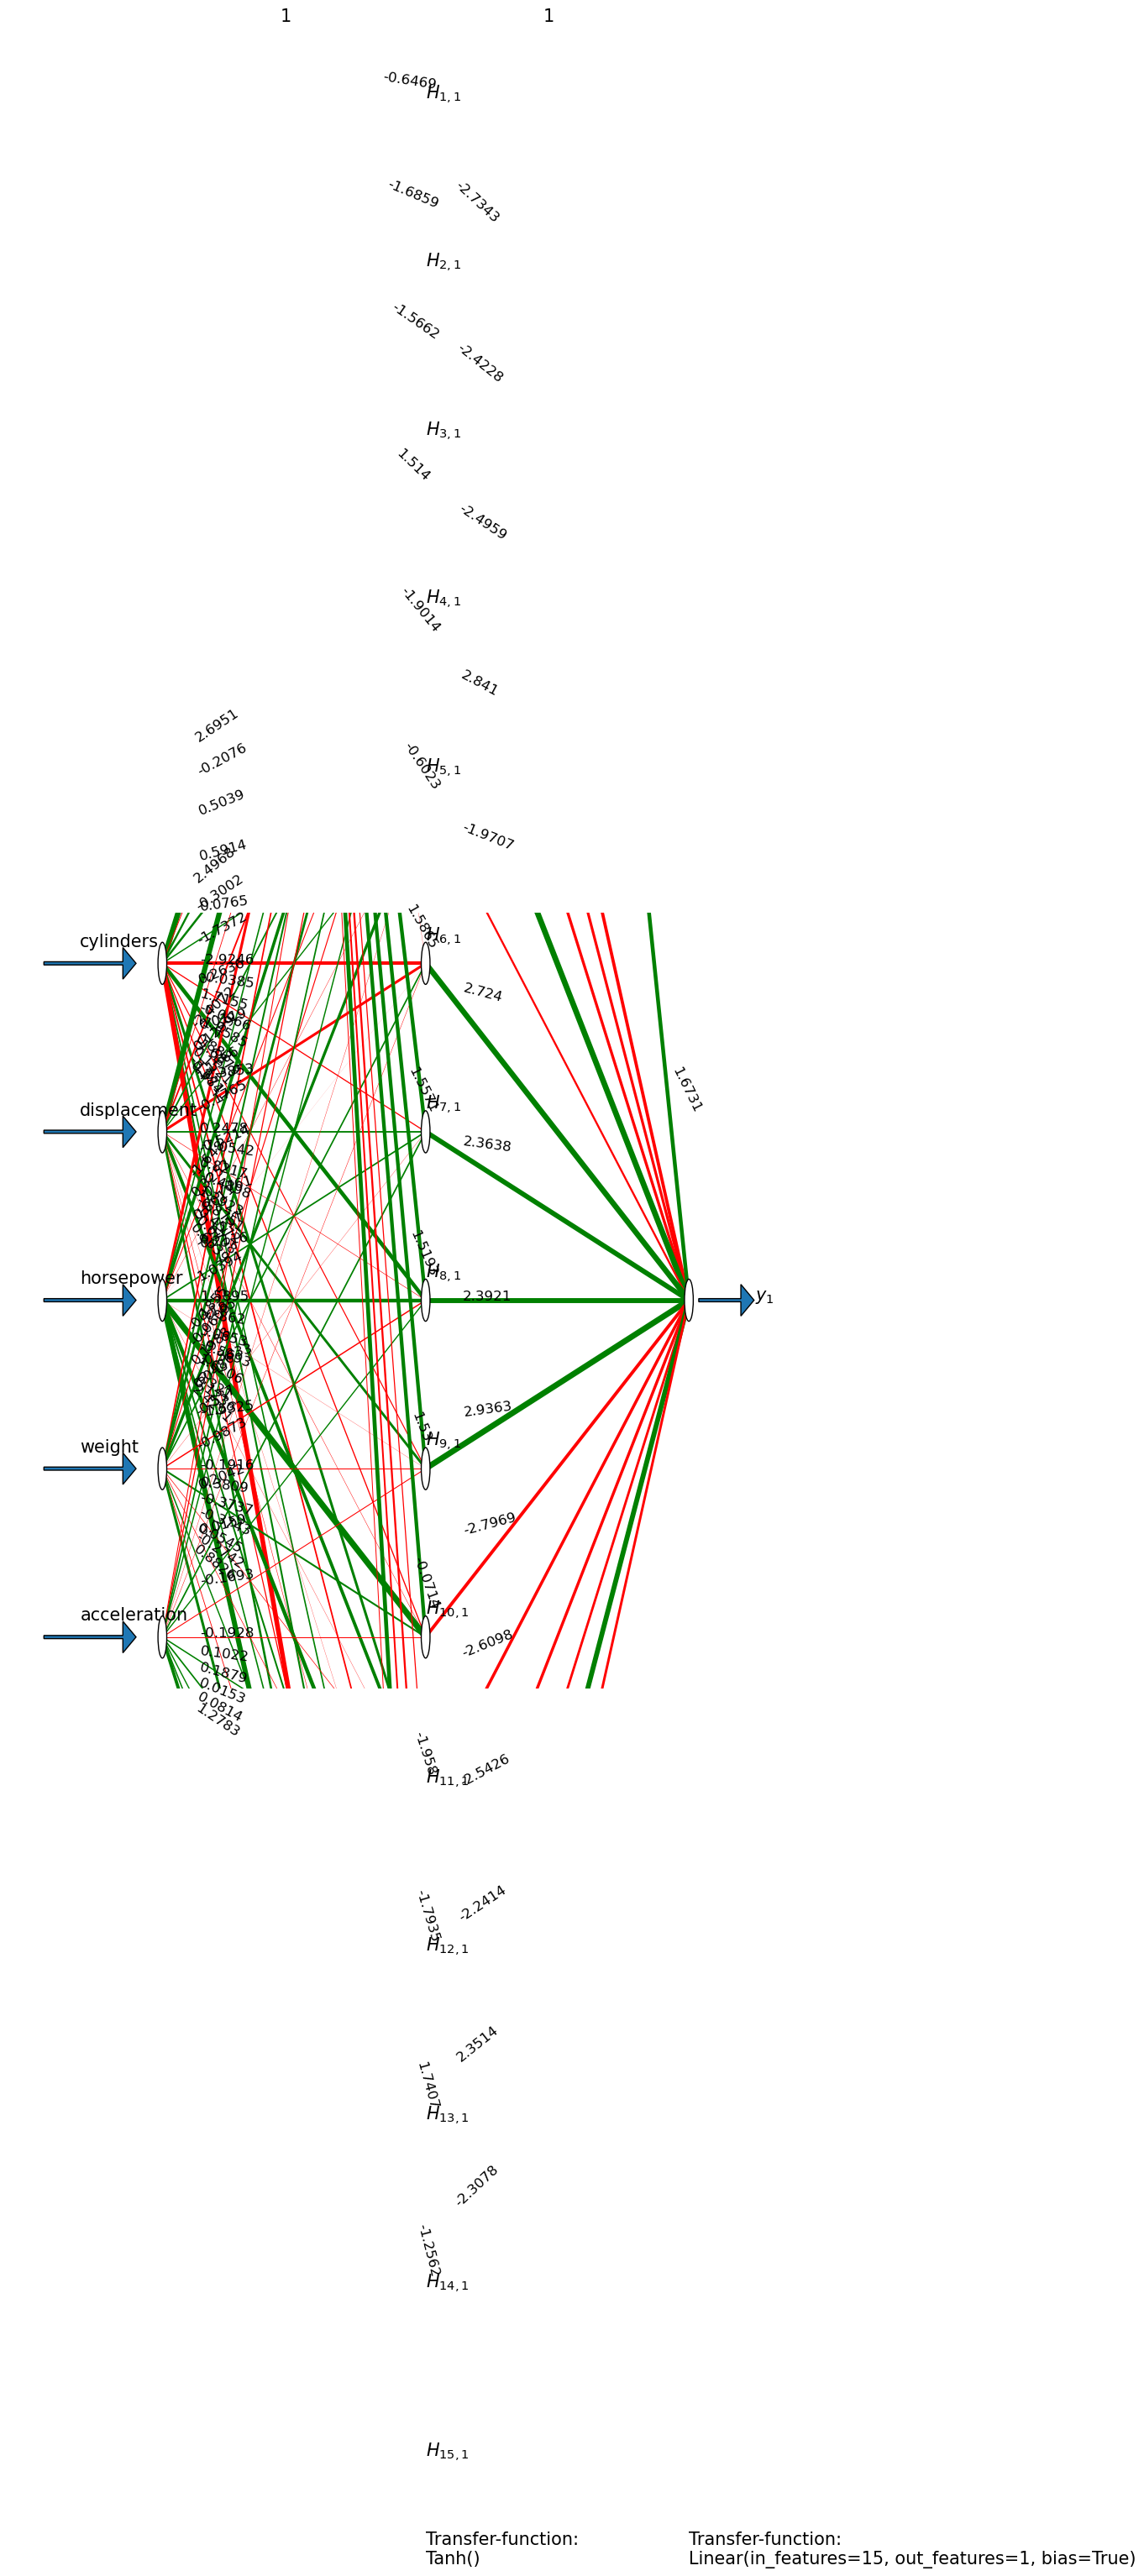


Estimated generalization error, RMSE: 3.9627


In [15]:
X = df_continous.values[:, 1:]  # features
X = np.concatenate((np.ones((X.shape[0], 1)), X), 1) # bias for regularized linear regression
attributeNames = ["bias"] + list(df_continous.columns[1:])
y = df_continous.values[:, [0]]  # target
N, M = X.shape

# Range of hyperparameters
lambdas = np.logspace(-3, 1, 50)
hidden_units = np.linspace(1, 20, 5, dtype=int)

# Parameters for ANN training
max_iter = 8000
loss_fn = torch.nn.MSELoss()

# Create cross-validation partitions for evaluation
# ************
# TODO MUST BE 10x10: IF LESS IS FOR CODE TESTING ONLY
# ************
K = 5
K_internal = 3
CV = model_selection.KFold(K, shuffle=True)

# Initialize variables
w_lr = np.empty((M, K))
Error_train_lr = np.empty((K, 1))
Error_test_lr = np.empty((K, 1))

w_rlr = np.empty((M, K))
Error_train_rlr = np.empty((K, 1))
Error_test_rlr = np.empty((K, 1))

w_noreg = np.empty((M, K))
Error_train_nofeatures = np.empty((K, 1))
Error_test_nofeatures = np.empty((K, 1))

w_ann = np.empty((M, K))
Error_train_ann = np.empty((K, 1))
Error_test_ann = np.empty((K, 1))

# Setup figure for display of learning curves and error rates in fold
summaries, summaries_axes = plt.subplots(1, 2, figsize=(10, 5))
color_list = [
    "tab:orange", "tab:green", "tab:purple", "tab:brown", "tab:pink",
    "tab:gray", "tab:olive", "tab:cyan", "tab:red", "tab:blue"
]

for k, (train_index, test_index) in enumerate(CV.split(X, y)):
    # Extract training and test set for current CV fold
    X_train, y_train = X[train_index], y[train_index]
    X_test, y_test = X[test_index], y[test_index]

    # Regularized linear regression
    opt_val_err, opt_lambda, mean_w_vs_lambda, train_err_vs_lambda, test_err_vs_lambda = rlr_validate(X_train, y_train, lambdas, K_internal)
    
    # Standardize outer fold based on training set
    X_train[:, 1:] = (X_train[:, 1:] - X_train[:, 1:].mean(0)) / X_train[:, 1:].std(0)
    X_test[:, 1:] = (X_test[:, 1:] - X_test[:, 1:].mean(0)) / X_test[:, 1:].std(0)

    # Compute mean squared error without features
    Error_train_nofeatures[k] = np.mean(np.square(y_train - y_train.mean()))
    Error_test_nofeatures[k] = np.mean(np.square(y_test - y_test.mean()))
    
    # Estimate weights and errors with regularization
    Xty, XtX = X_train.T @ y_train, X_train.T @ X_train
    lambdaI = opt_lambda * np.eye(M)
    lambdaI[0, 0] = 0 # Do not regularize the bias term
    
    w_rlr[:, k] = np.linalg.solve(XtX + lambdaI, Xty).squeeze()
    Error_train_rlr[k] = np.mean(np.square(y_train - X_train @ w_rlr[:, k]))
    Error_test_rlr[k] = np.mean(np.square(y_test - X_test @ w_rlr[:, k]))

    # Estimate weights and errors without regularization
    w_noreg[:, k] = np.linalg.solve(XtX, Xty).squeeze()
    Error_train_lr[k] = np.mean(np.square(y_train - X_train @ w_noreg[:, k]))
    Error_test_lr[k] = np.mean(np.square(y_test - X_test @ w_noreg[:, k]))

    # ANN training: find best H (number of hidden units) using internal CV
    best_h, best_mse = ann_validate(X_train[:, 1:], y_train, hidden_units, K_internal, max_iter)

    # Train final ANN with best H
    model = lambda: torch.nn.Sequential(
        torch.nn.Linear(M - 1, best_h),
        torch.nn.Tanh(),
        torch.nn.Linear(best_h, 1)
    )

    X_train, y_train, X_test, y_test = map(torch.Tensor, (X_train[:, 1:], y_train, X_test[:, 1:], y_test))

    net, final_loss, learning_curve = train_neural_net(
        model, 
        loss_fn, 
        X=X_train, 
        y=y_train, 
        n_replicates=3, 
        max_iter=max_iter
    )

    print(f"\n\nMSE for ANN with best h = {best_h} units on CV fold no. {k+1}/{K} ==> {final_loss}")
    
    y_train_est = net(X_train).detach()
    y_test_est = net(X_test).detach()
    Error_train_ann[k] = np.mean(np.square((y_train_est.float() - y_train.float()).numpy()))
    Error_test_ann[k] = np.mean(np.square((y_test_est.float() - y_test.float()).numpy()))

    # Display the learning curve for the best net in the current fold
    (h,) = summaries_axes[0].plot(learning_curve, label=f"CV fold {k + 1}", color=color_list[k])
    h.set_label(f"CV fold {k + 1}")
    summaries_axes[0].set_xlabel("Iterations")
    summaries_axes[0].set_xlim((0, max_iter))
    summaries_axes[0].legend(loc="best")
    summaries_axes[0].set_ylabel("Error")
    summaries_axes[0].grid(axis='y')
    summaries_axes[0].set_title("Learning curves")

# Display results

# Last cross-validation fold
summaries_axes[1].bar(np.arange(1, K + 1), np.squeeze(Error_test_ann), color=color_list)
summaries_axes[1].set_xlabel("Fold")
summaries_axes[1].set_xticks(np.arange(1, K + 1))
summaries_axes[1].set_ylabel("MSE")
summaries_axes[1].set_title("Test mean-squared-error")
plt.show()

# Statistics
print("Baseline (no features):")
print(f"- Training error: {Error_train_nofeatures.mean()}")
print(f"- Test error: {Error_test_nofeatures.mean()}\n")
print("Linear regression without feature selection (regularization):")
print(f"- Training error: {Error_train_lr.mean()}")
print(f"- Test error: {Error_test_lr.mean()}\n")
print("Regularized linear regression:")
print(f"- Training error: {Error_train_rlr.mean()}")
print(f"- Test error: {Error_test_rlr.mean()}\n")
print("Artificial Neural Network:")
print(f"- Training error: {Error_train_ann.mean()}")
print(f"- Test error: {Error_test_ann.mean()}\n")

# Draw the diagram of the best ANN from the last fold
print("Diagram of best neural net from the last fold:")
weights = [net[i].weight.data.numpy().T for i in [0, 2]]
biases = [net[i].bias.data.numpy() for i in [0, 2]]
tf = [str(net[i]) for i in [1, 2]]
draw_neural_net(weights, biases, tf, attribute_names=attributeNames[1:])

print(f"\nEstimated generalization error, RMSE: {round(np.sqrt(np.mean(Error_test_ann)), 4)}")